In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
import sys
from pathlib import Path

# Get the workspace root
workspace_root = Path.cwd().parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))
# Standard library imports
import copy
import pickle
import sys

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scripts.data_utils import load_nrm

# Local package imports - clustering
from scripts.clustering import core as sc
from scripts.clustering import shuffling as sh
#from scripts.clustering import evaluation_helpers as eval_helpers
#from scripts.clustering import distances as dist_helpers

# in distance.py, import of editdistance module is commented out

# Local package imports - visualization
from scripts.visualization import plots_clustering as pl
from scripts.visualization import plots_analysis as pa
from scripts.visualization import plots_simulation as ps
from scripts.visualization.style import set_plot_style, PublicationStandard

# Local package imports - analysis
from scripts.analysis import analysis as an
set_plot_style()

In [2]:
data_d= 'downsampled'
data_o= 'orig'

sigma_range= [1, 1]
vol_range= [0.07, 0.9]

with open(f'full_results_sig_{sigma_range[0]}_{sigma_range[1]}_vol_{vol_range[0]}_{vol_range[1]}.pkl', 'rb') as f:
    all_data = pickle.load(f)

#with open(f'use_these_pkls/30seed_counts_seqs_clusts_{data_o}_sig_{sigma_range}_vol_{vol_range}.pkl', 'rb') as f:
#    counts_orig = pickle.load(f)

KeyboardInterrupt: 

In [90]:
all_data[(1, 7)]['counts'].keys()

dict_keys(['count_seqs', 'count_clusters'])

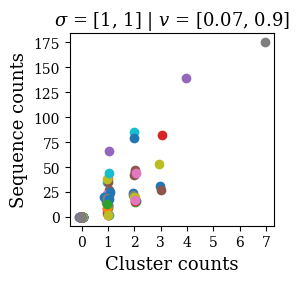

In [106]:
plt.figure(figsize=(3,3))
jitter_strength = 0.04

for sims in all_data.keys():
    jitter_down = np.random.normal(0, jitter_strength)
    counts_seqs = all_data[sims]['counts']['count_seqs']
    counts_clusters = all_data[sims]['counts']['count_clusters']
    plt.scatter(counts_clusters + jitter_down, counts_seqs)
    
plt.xticks(range(8), fontsize=10)
plt.yticks(fontsize=10)
plt.title(fr'$\sigma$ = {sigma_range} | $v$ = {vol_range}', fontsize=13)
plt.xlabel('Cluster counts', fontsize=13)
plt.ylabel('Sequence counts', fontsize=13)
plt.tight_layout()
plt.show()

In [2]:
param_sets = [
    ([1, 1], [0.07, 0.9]),
    ([1, 1], [0.07, 0.5]),
    ([1, 1], [0.1, 0.5]),
    ([0.02, 0.4], [0.07, 0.9]),
    ([0.02, 0.4], [0.07, 0.5]),
    ([0.02, 0.4], [0.1, 0.5])
]

loaded_plot_data_orig = {}
rd_orig = {}

for sigma_range, vol_range in param_sets:
    key = f"sig_{sigma_range[0]}_{sigma_range[1]}_vol_{vol_range[0]}_{vol_range[1]}"
    file_name = f'cluster_data/raw_full_results_{key}.pkl'
    
    try:
        with open(file_name, 'rb') as f:
            all_data = pickle.load(f)
            
        sim_data_list = []
        rd_s = []
        for sims in all_data.keys():
            sim_data_list.append({
                'clusters': all_data[sims]['counts']['count_clusters'],
                'seqs': all_data[sims]['counts']['count_seqs'],
                'sim': sims
            })
            rd_s.append({'rd_': all_data[sims]['rd_']})
        
        loaded_plot_data_orig[key] = sim_data_list
        rd_orig[key] = rd_s
        print(f"Successfully loaded: {file_name}")
        
    except FileNotFoundError:
        loaded_plot_data_orig[key] = None # Mark as missing
        print(f"Missing: {file_name}")

Successfully loaded: cluster_data/raw_full_results_sig_1_1_vol_0.07_0.9.pkl
Successfully loaded: cluster_data/raw_full_results_sig_1_1_vol_0.07_0.5.pkl
Successfully loaded: cluster_data/raw_full_results_sig_1_1_vol_0.1_0.5.pkl
Successfully loaded: cluster_data/raw_full_results_sig_0.02_0.4_vol_0.07_0.9.pkl
Successfully loaded: cluster_data/raw_full_results_sig_0.02_0.4_vol_0.07_0.5.pkl
Successfully loaded: cluster_data/raw_full_results_sig_0.02_0.4_vol_0.1_0.5.pkl


In [2]:
loaded_plot_data = {}
rd_down = {}

param_sets = [
    ([1, 1], [0.07, 0.9]),
    ([1, 1], [0.07, 0.5]),
    ([1, 1], [0.1, 0.5]),
    ([0.02, 0.4], [0.07, 0.9]),
    ([0.02, 0.4], [0.07, 0.5]),
    ([0.02, 0.4], [0.1, 0.5])
]


for sigma_range, vol_range in param_sets:
    key = f"sig_{sigma_range[0]}_{sigma_range[1]}_vol_{vol_range[0]}_{vol_range[1]}"
    file_name = f'cluster_data/full_results_{key}.pkl'
    
    try:
        with open(file_name, 'rb') as f:
            all_data = pickle.load(f)
            
        sim_data_list = []
        rd_s = []
        for sims in all_data.keys():
            sim_data_list.append({
                'clusters': all_data[sims]['counts']['count_clusters'],
                'seqs': all_data[sims]['counts']['count_seqs'],
                'sim': sims
            })
            rd_s.append({'rd_': all_data[sims]['rd_']})
        
        loaded_plot_data[key] = sim_data_list
        rd_down[key] = rd_s
        print(f"Successfully loaded: {file_name}")
        
    except FileNotFoundError:
        loaded_plot_data[key] = None # Mark as missing
        print(f"Missing: {file_name}")

Successfully loaded: cluster_data/full_results_sig_1_1_vol_0.07_0.9.pkl
Successfully loaded: cluster_data/full_results_sig_1_1_vol_0.07_0.5.pkl
Successfully loaded: cluster_data/full_results_sig_1_1_vol_0.1_0.5.pkl
Successfully loaded: cluster_data/full_results_sig_0.02_0.4_vol_0.07_0.9.pkl
Successfully loaded: cluster_data/full_results_sig_0.02_0.4_vol_0.07_0.5.pkl
Successfully loaded: cluster_data/full_results_sig_0.02_0.4_vol_0.1_0.5.pkl


In [3]:
counts_clust_down = {}
counts_clust_orig = {}

for i, (sigma_range, vol_range) in enumerate(param_sets):
    key = f"sig_{sigma_range[0]}_{sigma_range[1]}_vol_{vol_range[0]}_{vol_range[1]}"
    rd_ = rd_down[key][0]['rd_']
    red_ = an.sort_and_filter_labels(
    ids_clust=rd_["ids_clust"],
    clust_scores=rd_["clust_scores"],
    sort_by="within_clust",
    ascending=True,
    min_score={"within_clust": 0.4, "within_clust_ratio": 0},
    min_size=20,
    replace_with=-1,
    )
    s = np.unique(red_["ids_clust_replaced"], return_counts=True)
    sf_clust = s[1][np.where(s[0]>0)[0]]
    count_seqs_real= sf_clust.sum()
    count_clust_real= len(sf_clust)
    counts_clust_down[key] = count_clust_real
    
    rd_ = rd_orig[key][0]['rd_']
    red_ = an.sort_and_filter_labels(
    ids_clust=rd_["ids_clust"],
    clust_scores=rd_["clust_scores"],
    sort_by="within_clust",
    ascending=True,
    min_score={"within_clust": 0.4, "within_clust_ratio": 0},
    min_size=20,
    replace_with=-1,
    )
    s = np.unique(red_["ids_clust_replaced"], return_counts=True)
    sf_clust = s[1][np.where(s[0]>0)[0]]
    count_seqs_real= sf_clust.sum()
    count_clust_real= len(sf_clust)
    counts_clust_orig[key] = count_clust_real

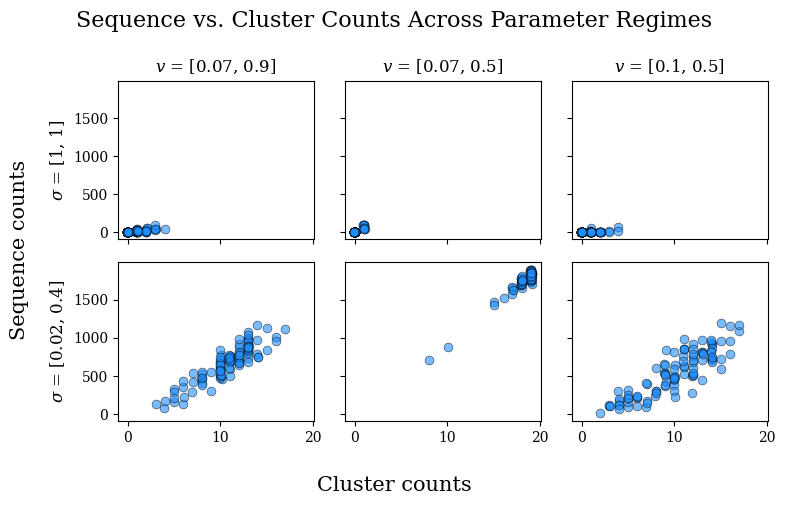

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(8, 5), sharex= True, sharey=True)
axes_flat = axes.flatten()

jitter_strength = 0.04

for i, (ax, (sigma_range, vol_range)) in enumerate(zip(axes_flat, param_sets)):
    key = f"sig_{sigma_range[0]}_{sigma_range[1]}_vol_{vol_range[0]}_{vol_range[1]}"
    
    sim_data_list = loaded_plot_data_orig.get(key)
    valid_count = counts_clust_orig.get(key)
    
    if sim_data_list is not None:
        label_added = False
        for sim in sim_data_list:
            jitter_down = np.random.normal(0, jitter_strength)

            if not label_added:
                lbl = f"Valid Count: {valid_count}"
                label_added = True
            else:
                lbl = "_no_legend_"
            
            ax.scatter(sim['clusters'] + jitter_down, sim['seqs'], 
                       color='dodgerblue', alpha=0.6, edgecolor='black', linewidth=0.5, s=40, label=lbl)

        if i < 3:
            ax.set_title(fr'$v$ = {vol_range}', fontsize=12)
        
        if i % 3 == 0:
            ax.set_ylabel(fr'$\sigma$ = {sigma_range}', fontsize=12)

        ax.tick_params(axis='both', which='major', labelsize=10)
        #ax.legend()
        
fig.supxlabel('Cluster counts', fontsize=15)
fig.supylabel('Sequence counts', fontsize=15)
plt.suptitle("Sequence vs. Cluster Counts Across Parameter Regimes", fontsize=16)
plt.tight_layout()
plt.savefig('raw_clustering_counts_wovalid.jpg', dpi = 300)  # rerun for without valid of downsampled cluster counts
plt.savefig('raw_clustering_counts_wovalid.pdf', dpi = 300)
plt.show()

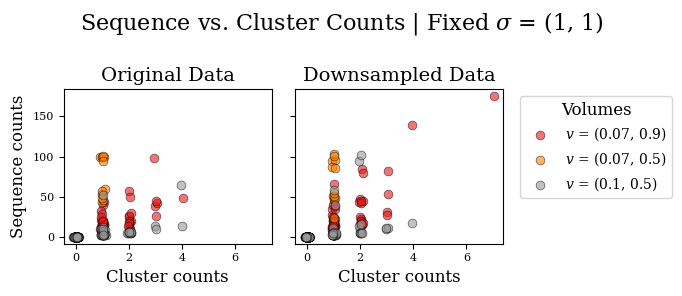

In [18]:
import matplotlib.pyplot as plt
import numpy as np

sigma_range = (1, 1)
vol_ranges = [
    (0.07, 0.9), 
    (0.07, 0.5),
    (0.1, 0.5)
]

colors = plt.cm.Set1(np.linspace(0, 1, len(vol_ranges)))
jitter_strength = 0.04

fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharex=True, sharey=True)

for v_idx, vol_range in enumerate(vol_ranges):
    key = f"sig_{sigma_range[0]}_{sigma_range[1]}_vol_{vol_range[0]}_{vol_range[1]}"
    
    color = colors[v_idx]
    label_text = fr'$v$ = {vol_range}'
    
    # ==========================================
    # 1. Plot ORIGINAL Data (Left Subplot: axes[0])
    # ==========================================
    sim_data_orig = loaded_plot_data_orig.get(key)
    if sim_data_orig is not None:
        for s_idx, sim in enumerate(sim_data_orig):
            jitter_down = np.random.normal(0, jitter_strength)
            
            # We only want to add the label to the legend ONCE per volume, not 30 times
            current_label = label_text if s_idx == 0 else ""
            
            axes[0].scatter(sim['clusters'] + jitter_down, sim['seqs'], 
                            color=color, alpha=0.6, edgecolor='black', 
                            linewidth=0.5, s=40, label=current_label)

    # ==============================================
    # 2. Plot DOWNSAMPLED Data (Right Subplot: axes[1])
    # ==============================================
    sim_data_down = loaded_plot_data.get(key)
    if sim_data_down is not None:
        for s_idx, sim in enumerate(sim_data_down):
            jitter_down = np.random.normal(0, jitter_strength)
            
            current_label = label_text if s_idx == 0 else ""
            
            axes[1].scatter(sim['clusters'] + jitter_down, sim['seqs'], 
                            color=color, alpha=0.6, edgecolor='black', 
                            linewidth=0.5, s=40, label=current_label)

axes[0].set_title('Original Data', fontsize=14)
axes[0].set_xlabel('Cluster counts', fontsize=12)
axes[0].set_ylabel('Sequence counts', fontsize=12)

axes[1].set_title('Downsampled Data', fontsize=14)
axes[1].set_xlabel('Cluster counts', fontsize=12)

axes[1].legend(title=fr"Volumes", 
               bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.suptitle(fr"Sequence vs. Cluster Counts | Fixed $\sigma$ = {sigma_range}", fontsize=16)
plt.tight_layout()
plt.savefig('(1,1)_sig_clustering_counts.jpg', dpi=300)
plt.savefig('(1,1)_sig_clustering_counts.pdf', dpi=300)
plt.show()

<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1207826/4009032636.py:47: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Sequence vs. Cluster Counts\n(Pooled for $\sigma$ = {sigma_range})', fontsize=16, pad=15)


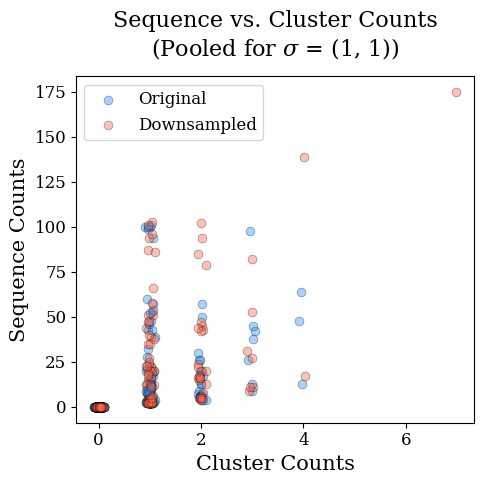

In [35]:
plt.figure(figsize=(5, 5))
jitter_strength = 0.04

# Trackers so we only add "Original" and "Downsampled" to the legend ONCE
added_orig_label = False
added_down_label = False

for v_idx, vol_range in enumerate(vol_ranges):
    key = f"sig_{sigma_range[0]}_{sigma_range[1]}_vol_{vol_range[0]}_{vol_range[1]}"

    # ==========================================
    # 1. Plot ORIGINAL Data 
    # ==========================================
    sim_data_orig = loaded_plot_data_orig.get(key)
    if sim_data_orig is not None:
        for s_idx, sim in enumerate(sim_data_orig):
            jitter_down = np.random.normal(0, jitter_strength)

            if not added_orig_label:
                lbl = 'Original'
                added_orig_label = True
            else:
                lbl = "_" + 'Original'
            
            plt.scatter(sim['clusters'] + jitter_down, sim['seqs'], 
                            color='dodgerblue', alpha=0.4, edgecolor='black', 
                            linewidth=0.5, s=40, label=lbl)

    # ==============================================
    # 2. Plot DOWNSAMPLED Data 
    # ==============================================
    sim_data_down = loaded_plot_data.get(key)
    if sim_data_down is not None:
        for s_idx, sim in enumerate(sim_data_down):
            jitter_down = np.random.normal(0, jitter_strength)
            
            if not added_down_label:
                lbl = 'Downsampled'
                added_down_label = True
            else:
                lbl = "_" + 'Downsampled'
            
            plt.scatter(sim['clusters'] + jitter_down, sim['seqs'], 
                            color='tomato', alpha=0.4, edgecolor='black', 
                            linewidth=0.5, s=40, label=lbl)

plt.title(f'Sequence vs. Cluster Counts\n(Pooled for $\sigma$ = {sigma_range})', fontsize=16, pad=15)
plt.xlabel('Cluster Counts', fontsize=15)
plt.ylabel('Sequence Counts', fontsize=15)

plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.savefig('pooled_(1,1)_clustering_counts.jpg', dpi=300)
plt.savefig('pooled_(1,1)_clustering_counts.pdf', dpi=300)
plt.show()

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

param_sets = [
    ([1, 1], [0.07, 0.9]),
    ([1, 1], [0.07, 0.5]),
    ([1, 1], [0.1, 0.5]),
    ([0.02, 0.4], [0.07, 0.9]),
    ([0.02, 0.4], [0.07, 0.5]),
    ([0.02, 0.4], [0.1, 0.5])
]

loaded_plot_data = {}

for sigma_range, vol_range in param_sets:
    key = f"sig_{sigma_range[0]}_{sigma_range[1]}_vol_{vol_range[0]}_{vol_range[1]}"
    file_name = f'full_results_{key}.pkl'
    
    try:
        with open(file_name, 'rb') as f:
            all_data = pickle.load(f)
            
        sim_data_list = []
        for sims in all_data.keys():
            sim_data_list.append({
                'clusters': all_data[sims]['counts']['count_clusters'],
                'seqs': all_data[sims]['counts']['count_seqs'],
                'sim': sims
            })
        
        loaded_plot_data[key] = sim_data_list
        print(f"Successfully loaded: {file_name}")
        
    except FileNotFoundError:
        loaded_plot_data[key] = None # Mark as missing
        print(f"Missing: {file_name}")

Successfully loaded: full_results_sig_1_1_vol_0.07_0.9.pkl
Successfully loaded: full_results_sig_1_1_vol_0.07_0.5.pkl
Successfully loaded: full_results_sig_1_1_vol_0.1_0.5.pkl
Successfully loaded: full_results_sig_0.02_0.4_vol_0.07_0.9.pkl
Successfully loaded: full_results_sig_0.02_0.4_vol_0.07_0.5.pkl
Successfully loaded: full_results_sig_0.02_0.4_vol_0.1_0.5.pkl


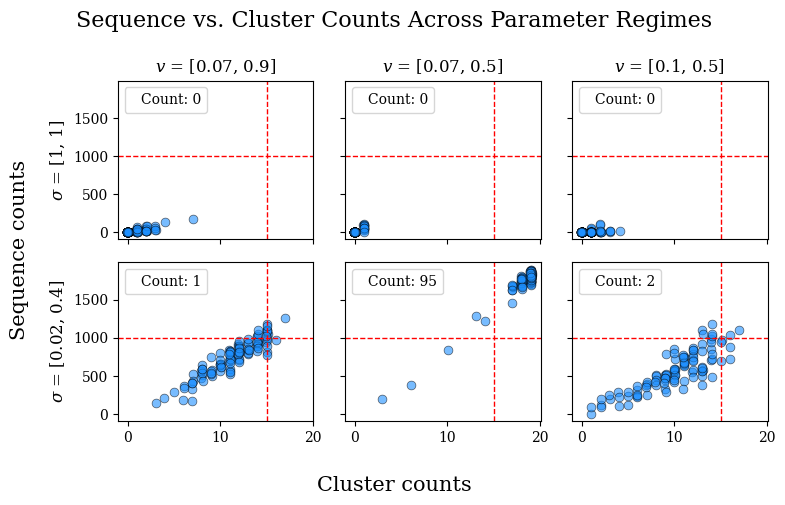

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(8, 5), sharex= True, sharey=True)
axes_flat = axes.flatten()

jitter_strength = 0.04

for i, (ax, (sigma_range, vol_range)) in enumerate(zip(axes_flat, param_sets)):
    key = f"sig_{sigma_range[0]}_{sigma_range[1]}_vol_{vol_range[0]}_{vol_range[1]}"
    
    sim_data_list = loaded_plot_data.get(key)
    
    if sim_data_list is not None:
        count = 0
        for sim in sim_data_list:
            jitter_down = np.random.normal(0, jitter_strength)
            
            ax.scatter(sim['clusters'] + jitter_down, sim['seqs'], 
                       color='dodgerblue', alpha=0.6, edgecolor='black', linewidth=0.5, s=40)

            if sim["clusters"] > 15 and sim["seqs"] > 1000:
                count += 1
                
        ax.plot([], [], ' ', label=f"Count: {count}")   
        ax.legend(loc='upper left', fontsize=10, handlelength=0)
        
        if i < 3:
            ax.set_title(fr'$v$ = {vol_range}', fontsize=12)
        
        if i % 3 == 0:
            ax.set_ylabel(fr'$\sigma$ = {sigma_range}', fontsize=12)

        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.axvline(15, color="red", linestyle="--")
        ax.axhline(1000, color="red", linestyle="--")
        
fig.supxlabel('Cluster counts', fontsize=15)
fig.supylabel('Sequence counts', fontsize=15)
plt.suptitle("Sequence vs. Cluster Counts Across Parameter Regimes", fontsize=16)
plt.tight_layout()
plt.savefig('subsample_clustering_counts_lines.jpg', dpi = 300)
plt.savefig('subsample_clustering_counts_lines.pdf', dpi = 300)
plt.show()

In [ ]:
counts_clust_down = {}
counts_clust_orig = {}

for i, (sigma_range, vol_range) in enumerate(param_sets):
    key = f"sig_{sigma_range[0]}_{sigma_range[1]}_vol_{vol_range[0]}_{vol_range[1]}"
    rd_ = rd_down[key][0]['rd_']
    red_ = an.sort_and_filter_labels(
    ids_clust=rd_["ids_clust"],
    clust_scores=rd_["clust_scores"],
    sort_by="within_clust",
    ascending=True,
    min_score={"within_clust": 0.4, "within_clust_ratio": 0},
    min_size=20,
    replace_with=-1,
    )
    s = np.unique(red_["ids_clust_replaced"], return_counts=True)
    sf_clust = s[1][np.where(s[0]>0)[0]]
    count_seqs_real= sf_clust.sum()
    count_clust_real= len(sf_clust)
    counts_clust_down[key] = count_clust_real

    rd_ = rd_orig[key][0]['rd_']
    red_ = an.sort_and_filter_labels(
    ids_clust=rd_["ids_clust"],
    clust_scores=rd_["clust_scores"],
    sort_by="within_clust",
    ascending=True,
    min_score={"within_clust": 0.4, "within_clust_ratio": 0},
    min_size=20,
    replace_with=-1,
    )
    s = np.unique(red_["ids_clust_replaced"], return_counts=True)
    sf_clust = s[1][np.where(s[0]>0)[0]]
    count_seqs_real= sf_clust.sum()
    count_clust_real= len(sf_clust)
    counts_clust_orig[key] = count_clust_real

In [17]:
counts_clust_down

{'sig_1_1_vol_0.07_0.9': 1,
 'sig_1_1_vol_0.07_0.5': 0,
 'sig_1_1_vol_0.1_0.5': 0,
 'sig_0.02_0.4_vol_0.07_0.9': 8,
 'sig_0.02_0.4_vol_0.07_0.5': 18,
 'sig_0.02_0.4_vol_0.1_0.5': 6}

In [ ]:
sigma_range = [0.02, 0.4]
vol_range = [0.07, 0.5]

best_key = f"sig_{sigma_range[0]}_{sigma_range[1]}_vol_{vol_range[0]}_{vol_range[1]}"
file_name = f'raw_full_results_{best_key}.pkl'

with open(f'cluster_data/{file_name}', 'rb') as f:
    best_data = pickle.load(f)

In [ ]:
best = sim_nums[best_key]
scores = best_data[best]["scores"]
rd_ = best_data[best]["rd_"]
seqs_labels = best_data[best]["seqs_labels"]

In [ ]:
mask = (
    (scores["survival_freq"] > 0.1) &
    (scores["pairwise_jaccard_cond_survival"] > 0.1))

pa.plot_survival_scores(
    scores,
    seqs_labels,
    "motif label",
    0.1, 0.1,
    figsize=(5,4),
    s=1,
    cmap="tab20"
)
sig_range = (0.02, 0.4)
vol_range = (0.07, 0.5)
plt.savefig(f"100sim_survival_scores_orig_{sig_range}_{vol_range}.jpg", dpi=300, bbox_inches="tight")
plt.savefig(f"100sim_survival_scores_orig_{sig_range}_{vol_range}.pdf", dpi=300, bbox_inches="tight")

In [ ]:
tbl = ps.plot_cluster_composition(seqs_labels, rd_["ids_clust"], normalize=False, sort="size", include_noise=True, 
                                  return_table=True, ratios=rd_["clust_scores"]["within_clust"])

plt.savefig(f"100sim_cluster_composition_orig_{sig_range}_{vol_range}.jpg", dpi=300, bbox_inches="tight")
plt.savefig(f"100sim_cluster_composition_orig_{sig_range}_{vol_range}.pdf", dpi=300, bbox_inches="tight")

In [ ]:
tbl = ps.plot_cluster_composition(seqs_labels, rd_["ids_clust"], normalize=False, sort="size", include_noise=True, thr=7,
                                  return_table=True,  ratios=rd_["clust_scores"]["within_clust_ratio"], ratios_label="Inter-cluster score")

plt.savefig(f"100sim_intercluster_composition_orig_{sig_range}_{vol_range}.jpg", dpi=300, bbox_inches="tight")
plt.savefig(f"100sim_intercluster_composition_orig_{sig_range}_{vol_range}.pdf", dpi=300, bbox_inches="tight")

In [39]:
counts_seqs = counts['counts_seqs']
counts_clusters = counts['counts_clusters']
counts_seqs_orig = counts_orig['counts_seqs']
counts_clusters_orig = counts_orig['counts_clusters']

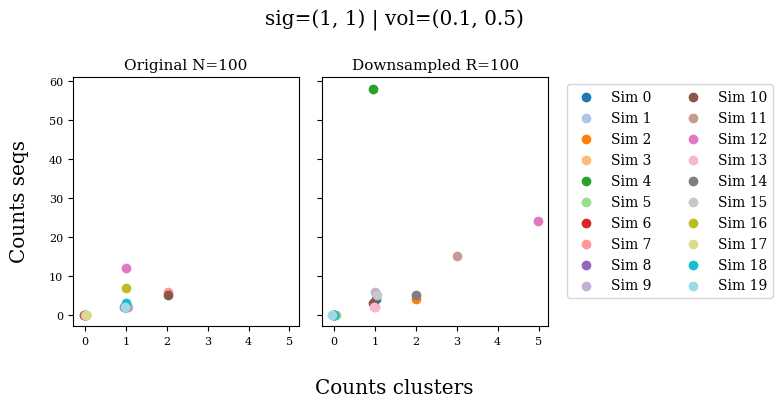

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharex= True, sharey=True)

colors = plt.get_cmap('tab20').colors
jitter_strength = 0.03

for i in range(20):
    jitter_orig = np.random.normal(0, jitter_strength)
    jitter_down = np.random.normal(0, jitter_strength)
    ax[0].scatter(counts_clusters_orig[i][0]+ jitter_orig, counts_seqs_orig[i][0], 
                  color=colors[i], label=f"Sim {i}")
    
    ax[1].scatter(counts_clusters[i][0]+ jitter_down, counts_seqs[i][0], 
                  color=colors[i], label=f"Sim {i}")
    
ax[0].set_title('Original N=100')
ax[1].set_title('Downsampled R=100')

fig.supxlabel('Counts clusters')
fig.supylabel('Counts seqs')

fig.suptitle(f"sig={sigma_range} | vol={vol_range}")
ax[1].legend(bbox_to_anchor=(1.05, 1), fontsize='small', ncol=2)
plt.tight_layout()
plt.show()